# Global Conflict Intelligence Analysis Using ACLED Data
## Objective
This project analyzes aggregated conflict event data from the Armed Conflict Location & Event Data Project (ACLED) to identify regional instability trends, escalation patterns, and conflict dynamics across the Middle East using Python-based analysis and visualization techniques.

# Import Libaries

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Overview
Source:
- Event, Conflict, and Exposure Data in the Middle East (ACLED)

Region:
- Middle East

Years Analyzed:
- 2014 - May 2026

Focus Areas:
- Conflcit Frequency
- Fatalities
- Event Types
- Regional Escalation Trends

In [114]:
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRlwynLb_JPxOrF1y8F48U0ST88gURT4LLNoiR4ULxgOBzpi27X1EmnrdN8A93AH_lJv9yG0-jFPFcH/pub?gid=3402845&single=true&output=csv"
acledME = pd.read_csv(url)

# Data Cleaning & Preparation
This section prepares and standardizes the dataset for exploratory conflict analysis and visualization.

In [115]:
acledME.columns = acledME.columns.str.strip().str.lower()
acledME['week'] = pd.to_datetime(acledME['week'])

In [116]:
countries = ['Israel', 'Lebanon', 'Syria', 'Iran', 'Palestine', 'Yemen' ]
acledME = acledME[acledME['country'].isin(countries)]
acledME = acledME.dropna(subset=['week','country'])

In [117]:
acledME['year'] = acledME['week'].dt.year
acledME['year_month'] = acledME['week'].dt.to_period('M')

# Regional Escalation Over Time
This visualization examines changes in escalation level across the Middle East.

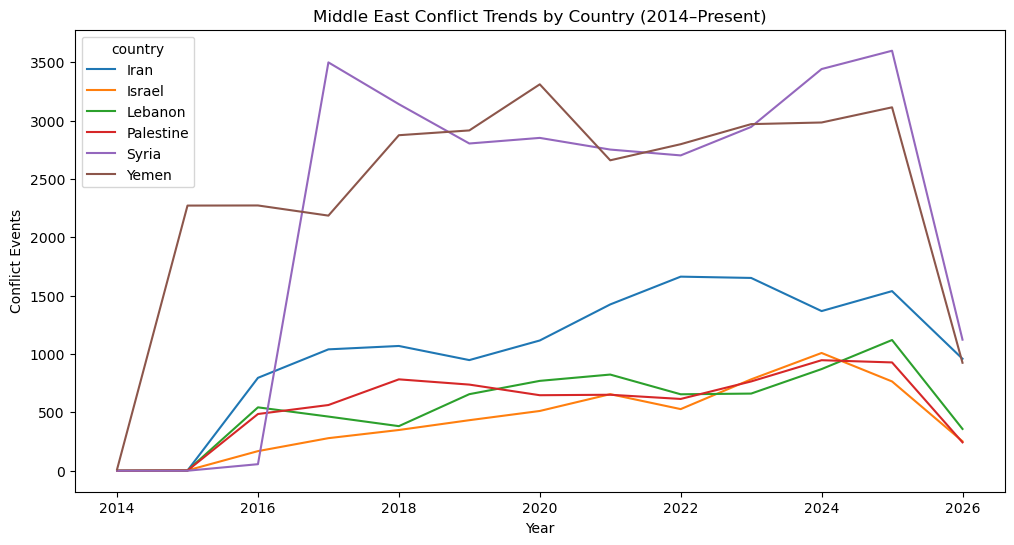

In [ ]:
yearly_trend = acledME.groupby(['year', 'country']).size().unstack().fillna(0)

yearly_trend.plot(figsize=(12,6))
plt.title("Middle East Conflict Trends by Country (2014–Present)")
plt.xlabel("Year")
plt.ylabel("Conflict Events")
plt.show()

### Key Findings
- Sharp increase in conflict events in Syria after 2016
- Consistent rise in escalation activity in Israel since 2015
- Several nations demonstrated sustained escalation trends

### Intelligence Implications
- Post 2016 escalation suggests conflict entrenchment and fragmentation
- Sustained escalation trend since 2015 indicates persistent low-to-high intensity volatility
- Multi-country sustained escalation patterns reflect broader regional system instability

# Fatality Index
The fatality index measures the intensity of conflict by comparing the number of fatalities per event across time and geography.

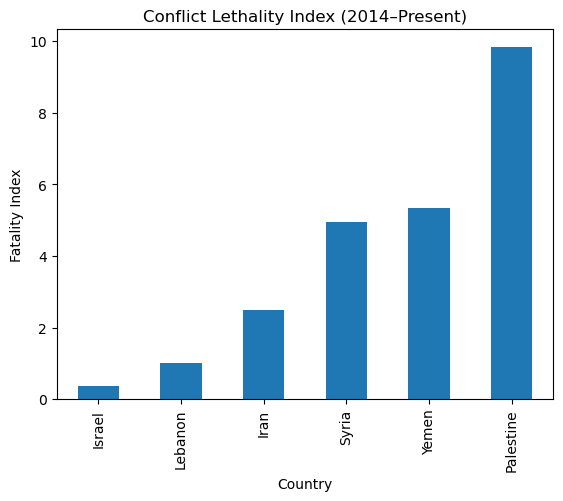

In [119]:
fatality_index = acledME.groupby('country').agg(
    events=('week', 'count'),
    fatalities=('fatalities', 'sum')
)

fatality_index['fatalities_per_event'] = (
    fatality_index['fatalities'] / fatality_index['events']
)

fatality_index['fatalities_per_event'].sort_values().plot(kind='bar')
plt.title("Conflict Lethality Index (2014–Present)")
plt.xlabel("Country")
plt.ylabel("Fatality Index")
plt.show()

### Key Findings
- Palestine holds the highest fatality index since 2014

### Intelligence Implications
- Palestine's high fatality index since 2014 indicates a prolonged high-intensity conflict environment

# Event Type Breakdown
This section categorizes conflict events into key operation types.

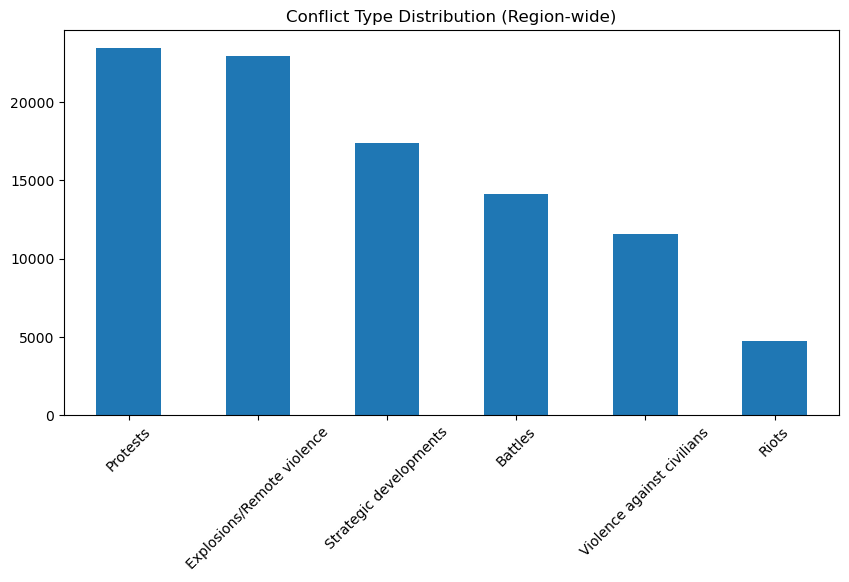

In [120]:
event_breakdown = acledME['event_type'].value_counts()

event_breakdown.plot(kind='bar', figsize=(10,5))
plt.title("Conflict Type Distribution (Region-wide)")
plt.xticks(rotation=45)
plt.show()

### Key Findings
- Non-violent protests are the most prevalent conflict type
- More violence against civilians than violence from civilians (riots)

### Intelligence Implications
- High prevalence of non-violent protests indicates sustained political mobilization and contested governance environments
- Greater incidence of violence against civilians compared to riots points to asymmetric coercion dynamics

# Country Conflict Dominance
This visualization highlights which countries contribute the highest share of national conflict events.

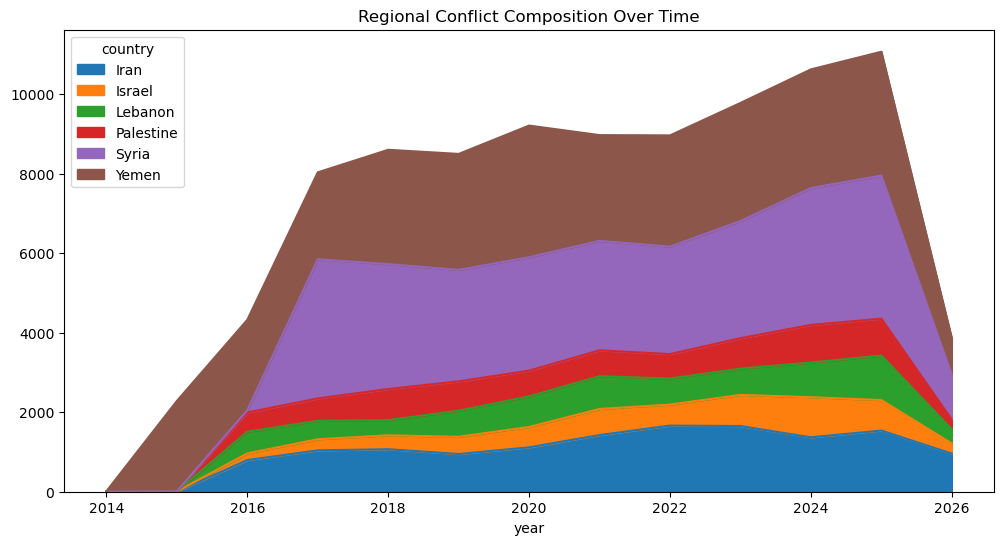

In [121]:
country_time = acledME.pivot_table(
    index='year',
    columns='country',
    values='week',
    aggfunc='count',
    fill_value=0
)

country_time.plot(kind='area', stacked=True, figsize=(12,6))
plt.title("Regional Conflict Composition Over Time")
plt.show()

### Key Findings
- Sharp escalation starting in 2015-2016 across majority of countries
- Sustained multi-country conflict activity

### Intelligence Implications
- The synchronized escalation beginning in 2015-2016 suggests a regional turning point in conflict dynamics
- Sustained multi-country activity indicates a regionalized conflict system rather than isolated national crises

# Subregional Hotspots
This visualization identifies geographic clusters of repeated violence within countries or across border regions.

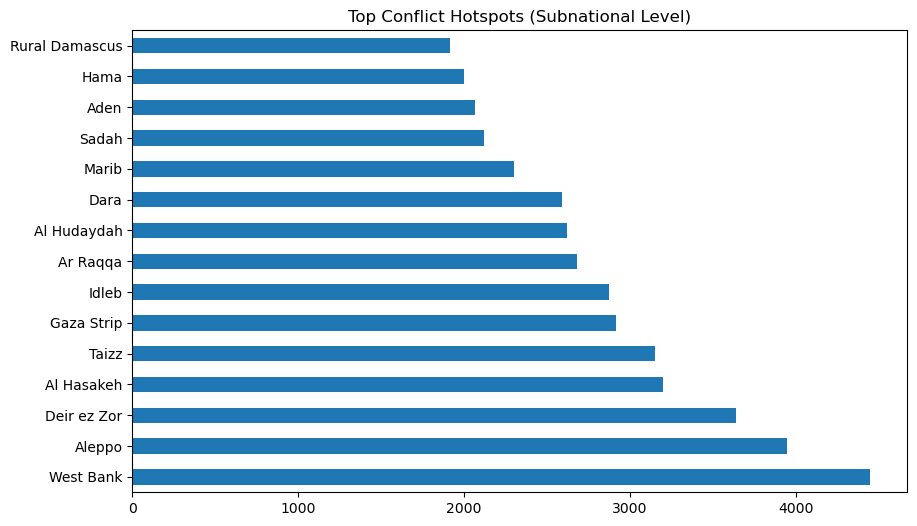

In [122]:
top_regions = acledME['area'].value_counts().head(15)

top_regions.plot(kind='barh', figsize=(10,6))
plt.title("Top Conflict Hotspots (Subnational Level)")
plt.show()

### Key Findings
- The West Bank of Palestine is the only hotspot with over 4000 events of violence
- The Gaza strip is considered a top 10 hotspot possibly due to the Palestine-Israeli conflict

### Intelligence Implications
- The geographic clustering of top hotspots within the same broader theater highlights conflict compression and spillover effects
- Gaza's status as a top-10 hotspot tied to the Israel-Palestine conflict reflects chronic high-intensity escalation dynamics 